# 🌱 KrishiTwin — XGBoost with Walk-Forward CV
## Data Leakage Fix + Yearly Pattern Learning
---
### Strategy:
- **Walk-Forward Split** → Model sirf past data dekhega, future nahi
- **Lag Features** → Model ko explicitly year-over-year pattern sikhate hain
- **Log Transform** → Skewed yield distributions fix
- **No Shuffle** → Time order hamesha preserve hoga

## CELL 1 — Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
warnings.filterwarnings('ignore')

!pip install xgboost
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error

print('✅ Libraries Loaded')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.3 MB/s eta 0:00:00
✅ Libraries Loaded


## CELL 2 — File Path (Yahan Apna Path Dalo)

In [2]:
# ============================================================
# 🔧 APNA FILE PATH YAHAN DALO
# ============================================================
DATA_PATH = '/content/KrishiTwin_Final_Engineered.csv'   # << Apna path
# ============================================================

df = pd.read_csv(DATA_PATH)
df.columns = [c.replace('..', '.').strip() for c in df.columns]

# Standardize common column name variants
rename_map = {
    'State.Name' : 'State Name',
    'dist.name'  : 'dist_name',
    'dist.code'  : 'dist_code',
}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

df = df.sort_values(['dist_code', 'year']).reset_index(drop=True)

print(f'✅ Data Loaded: {df.shape}')
print(f'   Year Range : {df["year"].min()} – {df["year"].max()}')
print(f'   Districts  : {df["dist_code"].nunique()}')
print(f'   States     : {df["State Name"].nunique()}')

✅ Data Loaded: (7841, 35)
   Year Range : 1990 – 2015
   Districts  : 302
   States     : 20


In [3]:
df

,dist_code,year,State Name,dist_name,RICE YIELD (Kg per ha),PEARL MILLET YIELD (Kg per ha),CHICKPEA YIELD (Kg per ha),GROUNDNUT YIELD (Kg per ha),SUGARCANE YIELD (Kg per ha),NPK_Intensity_KgHa,...,MINOR.PULSES.YIELD.Kg.per.ha.,SESAMUM.YIELD.Kg.per.ha.,RAPESEED.AND.MUSTARD.YIELD.Kg.per.ha.,SAFFLOWER.YIELD.Kg.per.ha.,CASTOR.YIELD.Kg.per.ha.,LINSEED.YIELD.Kg.per.ha.,SUNFLOWER.YIELD.Kg.per.ha.,SOYABEAN.YIELD.Kg.per.ha.,OILSEEDS.YIELD.Kg.per.ha.,COTTON.YIELD.Kg.per.ha.
0,1,1990,Chhattisgarh,durg,1210.0,0.0,572.0,848.0,0.0,25.758575,...,349.87,157.89,574.55,0.0,0.0,181.68,0.00,778.33,233.33,0.0
1,1,1991,Chhattisgarh,durg,1293.0,0.0,690.0,1040.0,1190.0,34.017668,...,499.44,142.86,576.35,500.0,0.0,261.43,250.00,657.68,300.93,0.0
2,1,1992,Chhattisgarh,durg,1291.0,0.0,626.0,1438.0,1667.0,42.239316,...,388.52,166.67,601.27,250.0,0.0,226.16,222.22,705.88,310.57,0.0
3,1,1993,Chhattisgarh,durg,1387.0,0.0,684.0,1042.0,2500.0,32.244130,...,428.48,166.67,504.79,250.0,0.0,208.43,304.35,887.81,389.69,0.0
4,1,1994,Chhattisgarh,durg,1399.0,0.0,725.0,1000.0,1000.0,35.144383,...,402.91,137.93,620.69,250.0,0.0,248.92,320.00,792.90,341.88,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7836,916,2011,Jharkhand,ranchi,2590.0,0.0,1074.0,0.0,0.0,282.163257,...,1000.00,0.00,660.00,0.0,0.0,0.00,0.00,0.00,660.00,0.0
7837,916,2012,Jharkhand,ranchi,2509.0,0.0,1042.0,0.0,0.0,191.368678,...,1000.00,0.00,956.83,0.0,0.0,0.00,0.00,0.00,956.83,0.0
7838,916,2013,Jharkhand,ranchi,2340.0,0.0,1367.0,0.0,0.0,117.456673,...,777.78,0.00,861.54,0.0,0.0,0.00,0.00,0.00,861.54,0.0
7839,916,2014,Jharkhand,ranchi,2608.0,0.0,1021.0,0.0,0.0,217.122830,...,1290.08,0.00,912.09,0.0,0.0,0.00,0.00,0.00,912.09,0.0


In [4]:
df['dist_name'] = df['dist_name'].str.lower().str.strip()
df['State Name'] = df['State Name'].str.lower().str.strip()

In [5]:
dist_mapping = dict(zip(df['dist_name'], df['dist_code']))

In [ ]:
dist_mapping

{'durg': 1,
 'bastar': 2,
 'raipur': 3,
 'bilaspur': 4,
 'raigarh': 5,
 'surguja': 6,
 'jabalpur': 7,
 'balaghat': 8,
 'chhindwara': 9,
 'narsinghpur': 10,
 'seoni / shivani': 11,
 'mandla': 12,
 'sagar': 13,
 'damoh': 14,
 'tikamgarh': 15,
 'chhatarpur': 16,
 'panna': 17,
 'rewa': 18,
 'sidhi': 19,
 'satna': 20,
 'shahdol': 21,
 'gwalior': 22,
 'shivpuri': 23,
 'guna': 24,
 'datia': 25,
 'morena': 26,
 'bhind': 27,
 'indore': 28,
 'ratlam': 29,
 'ujjain': 30,
 'mandsaur': 31,
 'dewas': 32,
 'dhar': 33,
 'jhabua': 34,
 'khargone / west nimar': 35,
 'khandwa / east nimar': 36,
 'sehore': 37,
 'raisen': 38,
 'vidisha': 39,
 'betul': 40,
 'rajgarh': 41,
 'shajapur': 42,
 'hoshangabad': 43,
 'srikakulam': 44,
 'visakhapatnam': 45,
 'east godavari': 46,
 'west godavari': 47,
 'krishna': 48,
 'guntur': 49,
 's.p.s. nellore': 50,
 'kurnool': 51,
 'ananthapur': 52,
 'kadapa ysr': 53,
 'chittoor': 54,
 'hyderabad': 55,
 'nizamabad': 56,
 'medak': 57,
 'mahabubnagar': 58,
 'nalgonda': 59,
 'wara

## CELL 3 — Feature Engineering
### Agar already engineered CSV hai to CELL 3 skip karo aur CELL 4 se shuru karo

In [ ]:
# ── Sirf tab run karo agar raw (non-engineered) CSV load kiya hai ──────────
# Agar tumhara CSV already KrishiTwin_Final_Engineered.csv hai
# (NPK_Intensity_KgHa, WDI etc. already present hain) toh ye cell skip karo

RUN_FE = False   # << True karo agar raw CSV load kiya hai

if RUN_FE:
    mendeley_crops = ['RICE', 'PEARL MILLET', 'CHICKPEA', 'GROUNDNUT', 'SUGARCANE']

    # Area/Crop cols may have dot-notation
    def get_col(df, keyword):
        matches = [c for c in df.columns if keyword.upper() in c.upper()]
        return matches[0] if matches else None

    total_fert  = get_col(df, 'TOTAL FERTILISER')
    gross_crop  = get_col(df, 'GROSS CROPPED AREA')
    gross_irr   = get_col(df, 'GROSS IRRIGATED AREA')
    rice_area   = get_col(df, 'RICE AREA')
    sugar_area  = get_col(df, 'SUGARCANE AREA')
    rice_yield  = get_col(df, 'RICE YIELD')

    df['NPK_Intensity_KgHa']       = df[total_fert] / df[gross_crop]
    df['Irrigation_Intensity_Ratio']= df[gross_irr]  / df[gross_crop]
    df['WDI']                       = (df[rice_area] + df[sugar_area]) / df[gross_crop]

    kharif_temp_cols = [c for c in df.columns if any(m in c for m in ['JUNE','JULY','AUGUST','SEPTEMBER','OCTOBER']) and 'MAXIMUM' in c and 'Winter' not in c and 'Rainy' not in c]
    kharif_rain_cols = [c for c in df.columns if any(m in c for m in ['JUNE','JULY','AUGUST','SEPTEMBER','OCTOBER']) and 'PERCIPITATION' in c and 'Rainy' not in c]
    rabi_temp_cols   = [c for c in df.columns if any(m in c for m in ['NOVEMBER','DECEMBER','JANUARY','FEBRUARY']) and 'MAXIMUM' in c and 'Winter' not in c]

    df['Kharif_Avg_MaxTemp'] = df[kharif_temp_cols].mean(axis=1)
    df['Kharif_Total_Rain']  = df[kharif_rain_cols].sum(axis=1)
    df['Rabi_Avg_MaxTemp']   = df[rabi_temp_cols].mean(axis=1)

    df['Soil_Absorption_Efficiency'] = df[rice_yield] / (df['NPK_Intensity_KgHa'] + 1)
    df['District_Soil_Health_Score'] = df.groupby('dist_code')['Soil_Absorption_Efficiency'].transform('mean')

    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    print('✅ Feature Engineering Done')
else:
    print('⏭️  FE Skipped — using pre-engineered CSV')

⏭️  FE Skipped — using pre-engineered CSV


In [6]:
df
pd.set_option('display.max_columns', None)

In [7]:
df

,dist_code,year,State Name,dist_name,RICE YIELD (Kg per ha),PEARL MILLET YIELD (Kg per ha),CHICKPEA YIELD (Kg per ha),GROUNDNUT YIELD (Kg per ha),SUGARCANE YIELD (Kg per ha),NPK_Intensity_KgHa,Irrigation_Intensity_Ratio,WDI,Kharif_Avg_MaxTemp,Kharif_Total_Rain,Rabi_Avg_MaxTemp,District_Soil_Health_Score,WHEAT.YIELD.Kg.per.ha.,KHARIF.SORGHUM.YIELD.Kg.per.ha.,RABI.SORGHUM.YIELD.Kg.per.ha.,SORGHUM.YIELD.Kg.per.ha.,PEARL.MILLET.YIELD.Kg.per.ha.,MAIZE.YIELD.Kg.per.ha.,FINGER.MILLET.YIELD.Kg.per.ha.,BARLEY.YIELD.Kg.per.ha.,PIGEONPEA.YIELD.Kg.per.ha.,MINOR.PULSES.YIELD.Kg.per.ha.,SESAMUM.YIELD.Kg.per.ha.,RAPESEED.AND.MUSTARD.YIELD.Kg.per.ha.,SAFFLOWER.YIELD.Kg.per.ha.,CASTOR.YIELD.Kg.per.ha.,LINSEED.YIELD.Kg.per.ha.,SUNFLOWER.YIELD.Kg.per.ha.,SOYABEAN.YIELD.Kg.per.ha.,OILSEEDS.YIELD.Kg.per.ha.,COTTON.YIELD.Kg.per.ha.
0,1,1990,chhattisgarh,durg,1210.0,0.0,572.0,848.0,0.0,25.758575,0.226781,0.524960,31.112,1490.460007,29.335000,22.533164,685.08,800.00,0.00,800.00,0.0,950.00,0.0,1000.0,1031.58,349.87,157.89,574.55,0.0,0.0,181.68,0.00,778.33,233.33,0.0
1,1,1991,chhattisgarh,durg,1293.0,0.0,690.0,1040.0,1190.0,34.017668,0.270240,0.518565,31.796,1138.270012,28.800000,22.533164,620.69,782.61,0.00,782.61,0.0,921.05,0.0,0.0,1041.10,499.44,142.86,576.35,500.0,0.0,261.43,250.00,657.68,300.93,0.0
2,1,1992,chhattisgarh,durg,1291.0,0.0,626.0,1438.0,1667.0,42.239316,0.281473,0.523945,32.140,1027.639984,28.380000,22.533164,365.42,909.09,0.00,909.09,0.0,1363.64,0.0,0.0,1035.09,388.52,166.67,601.27,250.0,0.0,226.16,222.22,705.88,310.57,0.0
3,1,1993,chhattisgarh,durg,1387.0,0.0,684.0,1042.0,2500.0,32.244130,0.280058,0.515183,32.224,1214.430000,28.677500,22.533164,704.14,1000.00,1416.67,1384.62,1000.0,1105.26,0.0,0.0,1086.71,428.48,166.67,504.79,250.0,0.0,208.43,304.35,887.81,389.69,0.0
4,1,1994,chhattisgarh,durg,1399.0,0.0,725.0,1000.0,1000.0,35.144383,0.284562,0.525718,31.282,1593.490021,28.695000,22.533164,805.48,666.67,0.00,666.67,0.0,895.83,0.0,0.0,1019.23,402.91,137.93,620.69,250.0,0.0,248.92,320.00,792.90,341.88,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7836,916,2011,jharkhand,ranchi,2590.0,0.0,1074.0,0.0,0.0,282.163257,0.112560,0.736846,30.352,1480.900032,26.100000,77.037681,1701.25,0.00,0.00,0.00,0.0,1909.86,968.1,0.0,1540.74,1000.00,0.00,660.00,0.0,0.0,0.00,0.00,0.00,660.00,0.0
7837,916,2012,jharkhand,ranchi,2509.0,0.0,1042.0,0.0,0.0,191.368678,0.139654,0.758243,30.928,1259.120022,25.222500,77.037681,1815.63,0.00,0.00,0.00,0.0,2116.31,0.0,0.0,1820.51,1000.00,0.00,956.83,0.0,0.0,0.00,0.00,0.00,956.83,0.0
7838,916,2013,jharkhand,ranchi,2340.0,0.0,1367.0,0.0,0.0,117.456673,0.123408,0.735018,30.408,1371.509995,24.980000,77.037681,1941.18,0.00,0.00,0.00,0.0,1936.72,0.0,0.0,1693.25,777.78,0.00,861.54,0.0,0.0,0.00,0.00,0.00,861.54,0.0
7839,916,2014,jharkhand,ranchi,2608.0,0.0,1021.0,0.0,0.0,217.122830,0.139654,0.719373,30.862,1021.559975,23.980000,77.037681,1806.02,0.00,0.00,0.00,0.0,2261.41,0.0,0.0,1901.41,1290.08,0.00,912.09,0.0,0.0,0.00,0.00,0.00,912.09,0.0


## CELL 4 — Lag Features
### Yearly Pattern sikhane ka core — Model ab year-over-year trend dekhega
```
Kyun Lag Features?
────────────────────────────────────────────────────────
XGBoost time ki sequence nahi jaanta.
Lag features explicitly batate hain:
  'Pichle saal NPK itna tha, usse pehle itna'
  'Temperature trend kya tha'
  'Rainfall 3 saal se badh rahi ya ghat rahi'
Tab model sikhta hai ki yearly changes yield ko kaise affect karti hain.
────────────────────────────────────────────────────────
```

In [8]:
# ── Columns jinke lag features banana hai ─────────────────────────────────
LAG_COLS = [
    'NPK_Intensity_KgHa',
    'Irrigation_Intensity_Ratio',
    'WDI',
    'Kharif_Avg_MaxTemp',
    'Kharif_Total_Rain',
    'Rabi_Avg_MaxTemp',
]

# ── Kitne saal ka lag chahiye ──────────────────────────────────────────────
LAG_YEARS = [1, 2, 3]   # Year-1, Year-2, Year-3

df = df.sort_values(['dist_code', 'year']).reset_index(drop=True)

for col in LAG_COLS:
    if col not in df.columns:
        print(f'⚠️  Column not found, skipping lag: {col}')
        continue
    for lag in LAG_YEARS:
        lag_col_name = f'{col}_Lag{lag}'
        # groupby dist_code so that lag doesn't bleed across districts
        df[lag_col_name] = df.groupby('dist_code')[col].shift(lag)

# ── YoY Change Features — trend direction batate hain ─────────────────────
# Eg: Kharif_Total_Rain_Delta1 = Rain(t) - Rain(t-1)
DELTA_COLS = ['Kharif_Avg_MaxTemp', 'Kharif_Total_Rain', 'NPK_Intensity_KgHa']
for col in DELTA_COLS:
    if col in df.columns:
        lag1 = f'{col}_Lag1'
        if lag1 in df.columns:
            df[f'{col}_Delta1'] = df[col] - df[lag1]

# ── 3-Year Rolling Mean — smooth trend ────────────────────────────────────
ROLLING_COLS = ['Kharif_Avg_MaxTemp', 'Kharif_Total_Rain']
for col in ROLLING_COLS:
    if col in df.columns:
        df[f'{col}_Roll3'] = (
            df.groupby('dist_code')[col]
              .transform(lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
        )
        # Note: shift(1) pehle kiya — current year ka data leak na ho

# ── Drop rows jahan lag values NaN hain (first 3 years per district) ──────
lag_feature_cols = [f'{c}_Lag{l}' for c in LAG_COLS for l in LAG_YEARS if c in df.columns]
df_lagged = df.dropna(subset=lag_feature_cols).reset_index(drop=True)

print(f'✅ Lag Features Created')
print(f'   Rows before lag drop : {len(df):,}')
print(f'   Rows after lag drop  : {len(df_lagged):,}  (first 3 yrs per district removed — expected)')
print(f'   New lag columns      : {len(lag_feature_cols)}')

✅ Lag Features Created
   Rows before lag drop : 7,841
   Rows after lag drop  : 6,935  (first 3 yrs per district removed — expected)
   New lag columns      : 18


In [9]:
df_lagged.shape

(6935, 58)

In [ ]:
df_lagged

,dist_code,year,State Name,dist_name,RICE YIELD (Kg per ha),PEARL MILLET YIELD (Kg per ha),CHICKPEA YIELD (Kg per ha),GROUNDNUT YIELD (Kg per ha),SUGARCANE YIELD (Kg per ha),NPK_Intensity_KgHa,Irrigation_Intensity_Ratio,WDI,Kharif_Avg_MaxTemp,Kharif_Total_Rain,Rabi_Avg_MaxTemp,District_Soil_Health_Score,WHEAT.YIELD.Kg.per.ha.,KHARIF.SORGHUM.YIELD.Kg.per.ha.,RABI.SORGHUM.YIELD.Kg.per.ha.,SORGHUM.YIELD.Kg.per.ha.,PEARL.MILLET.YIELD.Kg.per.ha.,MAIZE.YIELD.Kg.per.ha.,FINGER.MILLET.YIELD.Kg.per.ha.,BARLEY.YIELD.Kg.per.ha.,PIGEONPEA.YIELD.Kg.per.ha.,MINOR.PULSES.YIELD.Kg.per.ha.,SESAMUM.YIELD.Kg.per.ha.,RAPESEED.AND.MUSTARD.YIELD.Kg.per.ha.,SAFFLOWER.YIELD.Kg.per.ha.,CASTOR.YIELD.Kg.per.ha.,LINSEED.YIELD.Kg.per.ha.,SUNFLOWER.YIELD.Kg.per.ha.,SOYABEAN.YIELD.Kg.per.ha.,OILSEEDS.YIELD.Kg.per.ha.,COTTON.YIELD.Kg.per.ha.,NPK_Intensity_KgHa_Lag1,NPK_Intensity_KgHa_Lag2,NPK_Intensity_KgHa_Lag3,Irrigation_Intensity_Ratio_Lag1,Irrigation_Intensity_Ratio_Lag2,Irrigation_Intensity_Ratio_Lag3,WDI_Lag1,WDI_Lag2,WDI_Lag3,Kharif_Avg_MaxTemp_Lag1,Kharif_Avg_MaxTemp_Lag2,Kharif_Avg_MaxTemp_Lag3,Kharif_Total_Rain_Lag1,Kharif_Total_Rain_Lag2,Kharif_Total_Rain_Lag3,Rabi_Avg_MaxTemp_Lag1,Rabi_Avg_MaxTemp_Lag2,Rabi_Avg_MaxTemp_Lag3,Kharif_Avg_MaxTemp_Delta1,Kharif_Total_Rain_Delta1,NPK_Intensity_KgHa_Delta1,Kharif_Avg_MaxTemp_Roll3,Kharif_Total_Rain_Roll3
0,1,1993,chhattisgarh,durg,1387.0,0.0,684.0,1042.0,2500.0,32.244130,0.280058,0.515183,32.224,1214.430000,28.677500,22.533164,704.14,1000.00,1416.67,1384.62,1000.0,1105.26,0.0,0.0,1086.71,428.48,166.67,504.79,250.00,0.0,208.43,304.35,887.81,389.69,0.0,42.239316,34.017668,25.758575,0.281473,0.270240,0.226781,0.523945,0.518565,0.524960,32.140,31.796,31.112,1027.639984,1138.270012,1490.460007,28.380000,28.800000,29.335000,0.084000,186.790016,-9.995187,31.682667,1218.790001
1,1,1994,chhattisgarh,durg,1399.0,0.0,725.0,1000.0,1000.0,35.144383,0.284562,0.525718,31.282,1593.490021,28.695000,22.533164,805.48,666.67,0.00,666.67,0.0,895.83,0.0,0.0,1019.23,402.91,137.93,620.69,250.00,0.0,248.92,320.00,792.90,341.88,0.0,32.244130,42.239316,34.017668,0.280058,0.281473,0.270240,0.515183,0.523945,0.518565,32.224,32.140,31.796,1214.430000,1027.639984,1138.270012,28.677500,28.380000,28.800000,-0.942000,379.060020,2.900253,32.053333,1126.779999
2,1,1995,chhattisgarh,durg,1507.0,0.0,497.0,1125.0,1000.0,35.180497,0.287350,0.518796,32.528,1192.210018,28.632500,22.533164,714.29,1000.00,0.00,1000.00,0.0,1333.33,0.0,1000.0,854.30,253.92,186.05,481.48,666.67,0.0,172.10,333.33,864.75,328.14,0.0,35.144383,32.244130,42.239316,0.284562,0.280058,0.281473,0.525718,0.515183,0.523945,31.282,32.224,32.140,1593.490021,1214.430000,1027.639984,28.695000,28.677500,28.380000,1.246000,-401.280003,0.036114,31.882000,1278.520002
3,1,1996,chhattisgarh,durg,1486.0,0.0,760.0,1000.0,2000.0,35.769900,0.286679,0.506468,32.142,901.209999,29.342500,22.533164,803.87,666.67,0.00,666.67,1000.0,1281.25,0.0,0.0,976.19,443.26,155.56,500.00,500.00,0.0,273.94,333.33,688.89,422.60,0.0,35.180497,35.144383,32.244130,0.287350,0.284562,0.280058,0.518796,0.525718,0.515183,32.528,31.282,32.224,1192.210018,1593.490021,1214.430000,28.632500,28.695000,28.677500,-0.386000,-291.000019,0.589403,32.011333,1333.376680
4,1,1997,chhattisgarh,durg,1265.0,0.0,364.0,1091.0,1613.0,48.123741,0.293813,0.545439,32.280,888.940025,28.820000,22.533164,514.04,82.64,0.00,80.65,0.0,914.29,0.0,0.0,595.04,40.02,133.33,384.62,333.33,0.0,130.92,250.00,793.83,417.56,0.0,35.769900,35.180497,35.144383,0.286679,0.287350,0.284562,0.506468,0.518796,0.525718,32.142,32.528,31.282,901.209999,1192.210018,1593.490021,29.342500,28.632500,28.695000,0.138000,-12.269974,12.353841,31.984000,1228.970013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6930,916,2011,jharkhand,ranchi,2590.0,0.0,1074.0,0.0,0.0,282.163257,0.112560,0

## CELL 5 — Melt to Long Format + Encode

In [10]:
# ── Yield columns identify karo ───────────────────────────────────────────
all_yield_cols = [c for c in df_lagged.columns if 'YIELD' in c.upper()]

# Pearl Millet duplicate remove
yield_cols = []
for c in all_yield_cols:
    if 'PEARL' in c.upper() and 'MILLET' in c.upper():
        if c == 'PEARL MILLET YIELD (Kg per ha)':
            yield_cols.append(c)
    else:
        yield_cols.append(c)

print(f'✅ Yield columns selected: {len(yield_cols)}')

# ── ID cols — sab features jo melt ke baad bhi chahiye ────────────────────
base_features = [
    'NPK_Intensity_KgHa', 'Irrigation_Intensity_Ratio', 'WDI',
    'Kharif_Avg_MaxTemp', 'Kharif_Total_Rain', 'Rabi_Avg_MaxTemp',
    'District_Soil_Health_Score'
]
lag_features  = [c for c in df_lagged.columns if '_Lag' in c or '_Delta' in c or '_Roll' in c]

id_cols = ['dist_code', 'year', 'State Name'] + base_features + lag_features
id_cols = [c for c in id_cols if c in df_lagged.columns]  # safety check

# ── Melt ──────────────────────────────────────────────────────────────────
df_melted = df_lagged.melt(
    id_vars=id_cols,
    value_vars=yield_cols,
    var_name='Crop_Type',
    value_name='Yield'
)
print(f'✅ Data Melted: {df_melted.shape}')
df_melted = df_melted[df_melted['Yield'] > 0].reset_index(drop=True)
print(f'✅ After filtering non-positive yields: {df_melted.shape}')

# ── Label Encoding ────────────────────────────────────────────────────────
le_crop  = LabelEncoder()
le_state = LabelEncoder()
df_melted['Crop_Encoded']  = le_crop.fit_transform(df_melted['Crop_Type'])
df_melted['State_Encoded'] = le_state.fit_transform(df_melted['State Name'])

# Save encoders
joblib.dump(le_crop,  'crop_encoder.pkl')
joblib.dump(le_state, 'state_encoder.pkl')

print(f'✅ Melted shape     : {df_melted.shape}')
print(f'   Unique crops    : {df_melted["Crop_Type"].nunique()}')
print(f'   Year range      : {df_melted["year"].min()} – {df_melted["year"].max()}')
print(f'   Mean Yield      : {df_melted["Yield"].mean():.1f} Kg/ha')
print('✅ Encoders saved: crop_encoder.pkl, state_encoder.pkl')

✅ Yield columns selected: 23
✅ Data Melted: (159505, 35)
✅ After filtering non-positive yields: (101907, 35)
✅ Melted shape     : (101907, 37)
   Unique crops    : 23
   Year range      : 1993 – 2015
   Mean Yield      : 1325.4 Kg/ha
✅ Encoders saved: crop_encoder.pkl, state_encoder.pkl


In [11]:
df_melted.head()

,dist_code,year,State Name,NPK_Intensity_KgHa,Irrigation_Intensity_Ratio,WDI,Kharif_Avg_MaxTemp,Kharif_Total_Rain,Rabi_Avg_MaxTemp,District_Soil_Health_Score,NPK_Intensity_KgHa_Lag1,NPK_Intensity_KgHa_Lag2,NPK_Intensity_KgHa_Lag3,Irrigation_Intensity_Ratio_Lag1,Irrigation_Intensity_Ratio_Lag2,Irrigation_Intensity_Ratio_Lag3,WDI_Lag1,WDI_Lag2,WDI_Lag3,Kharif_Avg_MaxTemp_Lag1,Kharif_Avg_MaxTemp_Lag2,Kharif_Avg_MaxTemp_Lag3,Kharif_Total_Rain_Lag1,Kharif_Total_Rain_Lag2,Kharif_Total_Rain_Lag3,Rabi_Avg_MaxTemp_Lag1,Rabi_Avg_MaxTemp_Lag2,Rabi_Avg_MaxTemp_Lag3,Kharif_Avg_MaxTemp_Delta1,Kharif_Total_Rain_Delta1,NPK_Intensity_KgHa_Delta1,Kharif_Avg_MaxTemp_Roll3,Kharif_Total_Rain_Roll3,Crop_Type,Yield,Crop_Encoded,State_Encoded
0,1,1993,chhattisgarh,32.244130,0.280058,0.515183,32.224,1214.430000,28.6775,22.533164,42.239316,34.017668,25.758575,0.281473,0.270240,0.226781,0.523945,0.518565,0.524960,32.140,31.796,31.112,1027.639984,1138.270012,1490.460007,28.3800,28.8000,29.3350,0.084,186.790016,-9.995187,31.682667,1218.790001,RICE YIELD (Kg per ha),1387.0,15,3
1,1,1994,chhattisgarh,35.144383,0.284562,0.525718,31.282,1593.490021,28.6950,22.533164,32.244130,42.239316,34.017668,0.280058,0.281473,0.270240,0.515183,0.523945,0.518565,32.224,32.140,31.796,1214.430000,1027.639984,1138.270012,28.6775,28.3800,28.8000,-0.942,379.060020,2.900253,32.053333,1126.779999,RICE YIELD (Kg per ha),1399.0,15,3
2,1,1995,chhattisgarh,35.180497,0.287350,0.518796,32.528,1192.210018,28.6325,22.533164,35.144383,32.244130,42.239316,0.284562,0.280058,0.281473,0.525718,0.515183,0.523945,31.282,32.224,32.140,1593.490021,1214.430000,1027.639984,28.6950,28.6775,28.3800,1.246,-401.280003,0.036114,31.882000,1278.520002,RICE YIELD (Kg per ha),1507.0,15,3
3,1,1996,chhattisgarh,35.769900,0.286679,0.506468,32.142,901.209999,29.3425,22.533164,35.180497,35.144383,32.244130,0.287350,0.284562,0.280058,0.518796,0.525718,0.515183,32.528,31.282,32.224,1192.210018,1593.490021,1214.430000,28.6325,28.6950,28.6775,-0.386,-291.000019,0.589403,32.011333,1333.376680,RICE YIELD (Kg per ha),1486.0,15,3
4,1,1997,chhattisgarh,48.123741,0.293813,0.545439,32.280,888.940025,28.8200,22.533164,35.769900,35.180497,35.144383,0.286679,0.287350,0.284562,0.506468,0.518796,0.525718,32.142,32.528,31.282,901.209999,1192.210018,1593.490021,29.3425,28.6325,28.6950,0.138,-12.269974,12.353841,31.984000,1228.970013,RICE YIELD (Kg per ha),1265.0,15,3


In [12]:
for i, crop in enumerate(le_crop.classes_):
    print(f"{crop} → {i}")

BARLEY.YIELD.Kg.per.ha. → 0
CASTOR.YIELD.Kg.per.ha. → 1
CHICKPEA YIELD (Kg per ha) → 2
COTTON.YIELD.Kg.per.ha. → 3
FINGER.MILLET.YIELD.Kg.per.ha. → 4
GROUNDNUT YIELD (Kg per ha) → 5
KHARIF.SORGHUM.YIELD.Kg.per.ha. → 6
LINSEED.YIELD.Kg.per.ha. → 7
MAIZE.YIELD.Kg.per.ha. → 8
MINOR.PULSES.YIELD.Kg.per.ha. → 9
OILSEEDS.YIELD.Kg.per.ha. → 10
PEARL MILLET YIELD (Kg per ha) → 11
PIGEONPEA.YIELD.Kg.per.ha. → 12
RABI.SORGHUM.YIELD.Kg.per.ha. → 13
RAPESEED.AND.MUSTARD.YIELD.Kg.per.ha. → 14
RICE YIELD (Kg per ha) → 15
SAFFLOWER.YIELD.Kg.per.ha. → 16
SESAMUM.YIELD.Kg.per.ha. → 17
SORGHUM.YIELD.Kg.per.ha. → 18
SOYABEAN.YIELD.Kg.per.ha. → 19
SUGARCANE YIELD (Kg per ha) → 20
SUNFLOWER.YIELD.Kg.per.ha. → 21
WHEAT.YIELD.Kg.per.ha. → 22


In [13]:
for i, state in enumerate(le_state.classes_):
    print(f"{state} → {i}")

andhra pradesh → 0
assam → 1
bihar → 2
chhattisgarh → 3
gujarat → 4
haryana → 5
himachal pradesh → 6
jharkhand → 7
karnataka → 8
kerala → 9
madhya pradesh → 10
maharashtra → 11
orissa → 12
punjab → 13
rajasthan → 14
tamil nadu → 15
telangana → 16
uttar pradesh → 17
uttarakhand → 18
west bengal → 19


## CELL 6 — Walk-Forward Cross Validation
```
Walk-Forward Split kaise kaam karta hai:
────────────────────────────────────────────────────────────────
Fold 1:  Train = 1993–2005  │  Test = 2006
Fold 2:  Train = 1993–2006  │  Test = 2007
Fold 3:  Train = 1993–2007  │  Test = 2008
  ...         ...           │    ...
Fold N:  Train = 1993–2014  │  Test = 2015

✅ Model kabhi future data nahi dekhta
✅ Har fold mein window badh ti jaati hai
✅ Real production scenario ka perfect simulation
────────────────────────────────────────────────────────────────
```

In [14]:
def walk_forward_split(df, year_col='year', min_train_years=10, test_window=1):
    """
    Walk-Forward splits generate karta hai.

    min_train_years : minimum kitne saal ka train data chahiye
    test_window     : har fold mein kitne saal ka test (1 = single year)

    Returns list of (train_idx, test_idx) tuples.
    """
    years     = sorted(df[year_col].unique())
    min_year  = years[0]
    splits    = []

    for i in range(min_train_years, len(years), test_window):
        test_years  = years[i : i + test_window]
        train_years = years[:i]

        if not test_years:
            break

        train_idx = df[df[year_col].isin(train_years)].index
        test_idx  = df[df[year_col].isin(test_years)].index

        splits.append((train_idx, test_idx))

    return splits, years


splits, all_years = walk_forward_split(df_melted, year_col='year', min_train_years=10)

print(f'✅ Walk-Forward Splits Generated: {len(splits)} folds')
print(f'   Training starts from year    : {all_years[0]}')
print()
print(f'   {"Fold":<6} {"Train Range":<20} {"Test Year"}')
print('   ' + '-' * 40)
for i, (tr, te) in enumerate(splits):
    train_yrs = df_melted.loc[tr, 'year']
    test_yrs  = df_melted.loc[te, 'year']
    print(f'   {i+1:<6} {train_yrs.min()}–{train_yrs.max():<15} {test_yrs.min()}–{test_yrs.max()}')

✅ Walk-Forward Splits Generated: 13 folds
   Training starts from year    : 1993

   Fold   Train Range          Test Year
   ----------------------------------------
   1      1993–2002            2003–2003
   2      1993–2003            2004–2004
   3      1993–2004            2005–2005
   4      1993–2005            2006–2006
   5      1993–2006            2007–2007
   6      1993–2007            2008–2008
   7      1993–2008            2009–2009
   8      1993–2009            2010–2010
   9      1993–2010            2011–2011
   10     1993–2011            2012–2012
   11     1993–2012            2013–2013
   12     1993–2013            2014–2014
   13     1993–2014            2015–2015


## Kharif-Rabi SPLIT:-

In [15]:
# ── Crop Group Split ───────────────────────────────────────────────────────
KHARIF_CROPS = [c for c in df_melted['Crop_Type'].unique()
                if any(k in c.upper() for k in ['RICE', 'PEARL MILLET', 'GROUNDNUT', 'SUGARCANE'])]

RABI_CROPS   = [c for c in df_melted['Crop_Type'].unique()
                if any(k in c.upper() for k in ['CHICKPEA', 'WHEAT', 'LENTIL', 'MUSTARD'])]

df_kharif = df_melted[df_melted['Crop_Type'].isin(KHARIF_CROPS)].reset_index(drop=True)
df_rabi   = df_melted[df_melted['Crop_Type'].isin(RABI_CROPS)].reset_index(drop=True)

print(f"Kharif crops : {KHARIF_CROPS}")
print(f"Rabi crops   : {RABI_CROPS}")
print(f"Kharif rows  : {df_kharif.shape}")
print(f"Rabi rows    : {df_rabi.shape}")

Kharif crops : ['RICE YIELD (Kg per ha)', 'PEARL MILLET YIELD (Kg per ha)', 'GROUNDNUT YIELD (Kg per ha)', 'SUGARCANE YIELD (Kg per ha)']
Rabi crops   : ['CHICKPEA YIELD (Kg per ha)', 'WHEAT.YIELD.Kg.per.ha.', 'RAPESEED.AND.MUSTARD.YIELD.Kg.per.ha.']
Kharif rows  : (21478, 37)
Rabi rows    : (17115, 37)


# ═══════════════════════════════════════════════════════════════
# CELL 8A — KHARIF MODEL
# RandomizedSearchCV + GPU + Walk-Forward CV
# Rabi_Avg_MaxTemp EXCLUDED (future leakage for Kharif crops)
# ═══════════════════════════════════════════════════════════════


In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 8A — KHARIF MODEL
# RandomizedSearchCV + GPU + Walk-Forward CV
# Rabi_Avg_MaxTemp EXCLUDED (future leakage for Kharif crops)
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

# ── 1. Kharif Feature List ────────────────────────────────────────────────
kharif_base_features = [
    'year', 'State_Encoded', 'Crop_Encoded',
    'NPK_Intensity_KgHa', 'Irrigation_Intensity_Ratio', 'WDI',
    'Kharif_Avg_MaxTemp', 'Kharif_Total_Rain',
    # 'Rabi_Avg_MaxTemp'  ← EXCLUDED: measured after Kharif harvest (leakage)
    'District_Soil_Health_Score',
]

lag_features_k = [c for c in df_kharif.columns
                  if ('_Lag' in c or '_Delta' in c or '_Roll' in c)]

KHARIF_FEATURES = [f for f in kharif_base_features + lag_features_k
                   if f in df_kharif.columns]

print(f'✅ Kharif Total Features: {len(KHARIF_FEATURES)}')
for f in KHARIF_FEATURES:
    print(f'   {f}')

# ── 2. Prepare X, y ───────────────────────────────────────────────────────
X_kharif = df_kharif[KHARIF_FEATURES]
y_kharif_raw = df_kharif['Yield']
y_kharif_log = np.log1p(y_kharif_raw)

# ── 3. Walk-Forward Splits for Kharif ────────────────────────────────────
splits_kharif, _ = walk_forward_split(df_kharif, year_col='year', min_train_years=10)
print(f'\n✅ Kharif Walk-Forward Splits: {len(splits_kharif)} folds')

# ── 4. Param Grid ─────────────────────────────────────────────────────────
param_grid = {
    'n_estimators'     : [300, 500, 700],
    'max_depth'        : [4, 6, 8, 10],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.7, 0.8, 0.9],
    'colsample_bytree' : [0.7, 0.8, 0.9],
    'min_child_weight' : [3, 5, 7],
    'reg_lambda'       : [1.0, 1.5, 2.0, 5.0]
}

# ── 5. Base XGBoost with GPU ──────────────────────────────────────────────
xgb_base_k = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    device='cuda'
)

# ── 6. RandomizedSearchCV ─────────────────────────────────────────────────
print('\n⏳ Kharif RandomizedSearch chal raha hai...')

rs_kharif = RandomizedSearchCV(
    estimator=xgb_base_k,
    param_distributions=param_grid,
    n_iter=25,
    cv=splits_kharif,
    scoring='r2',
    n_jobs=1,
    verbose=1,
    random_state=42
)

rs_kharif.fit(X_kharif, y_kharif_log)

BEST_PARAMS_KHARIF = rs_kharif.best_params_
print(f'\n✅ Kharif Best Params:')
for k, v in BEST_PARAMS_KHARIF.items():
    print(f'   {k}: {v}')

# Add static GPU params
BEST_PARAMS_KHARIF['objective']    = 'reg:squarederror'
BEST_PARAMS_KHARIF['random_state'] = 42
BEST_PARAMS_KHARIF['tree_method']  = 'hist'
BEST_PARAMS_KHARIF['device']       = 'cuda'

# ── 7. Walk-Forward CV Loop (Tuned Params) ────────────────────────────────
fold_results_k = []
all_actuals_k  = []
all_preds_k    = []
all_years_k    = []

print('\n🚀 Kharif Walk-Forward Training (Tuned + GPU)...')
print(f'   {"Fold":<6} {"Test Year":<12} {"Train Rows":<12} {"Test Rows":<12} {"R2":>8} {"MAE":>10} {"MAPE":>8}')
print('   ' + '-' * 72)

for fold_num, (train_idx, test_idx) in enumerate(splits_kharif):
    X_train_k = X_kharif.loc[train_idx]
    X_test_k  = X_kharif.loc[test_idx]
    y_train_k = y_kharif_log.loc[train_idx]
    y_test_log_k = y_kharif_log.loc[test_idx]
    y_test_raw_k = y_kharif_raw.loc[test_idx]

    test_year = df_kharif.loc[test_idx, 'year'].min()

    model_fold_k = xgb.XGBRegressor(**BEST_PARAMS_KHARIF)
    model_fold_k.fit(
        X_train_k, y_train_k,
        eval_set=[(X_test_k, y_test_log_k)],
        verbose=False
    )

    preds_log_k = model_fold_k.predict(X_test_k)
    preds_raw_k = np.maximum(np.expm1(preds_log_k), 0)

    r2   = r2_score(y_test_raw_k, preds_raw_k)
    mae  = mean_absolute_error(y_test_raw_k, preds_raw_k)
    mape = np.mean(np.abs((y_test_raw_k - preds_raw_k) / y_test_raw_k.clip(lower=1))) * 100

    fold_results_k.append({'fold': fold_num+1, 'test_year': test_year,
                            'r2': r2, 'mae': mae, 'mape': mape,
                            'train_rows': len(train_idx), 'test_rows': len(test_idx)})
    all_actuals_k.extend(y_test_raw_k.tolist())
    all_preds_k.extend(preds_raw_k.tolist())
    all_years_k.extend([test_year] * len(test_idx))

    print(f'   {fold_num+1:<6} {test_year:<12} {len(train_idx):<12} {len(test_idx):<12} {r2:>8.4f} {mae:>10.1f} {mape:>7.1f}%')

# ── 8. Aggregate Kharif Metrics ───────────────────────────────────────────
results_df_k   = pd.DataFrame(fold_results_k)
overall_r2_k   = r2_score(all_actuals_k, all_preds_k)
overall_mae_k  = mean_absolute_error(all_actuals_k, all_preds_k)
overall_mape_k = np.mean(np.abs((np.array(all_actuals_k) - np.array(all_preds_k))
                                / np.array(all_actuals_k).clip(1))) * 100

print('   ' + '=' * 72)
print(f'   {"KHARIF OVERALL":<32} {overall_r2_k:>8.4f} {overall_mae_k:>10.1f} {overall_mape_k:>7.1f}%')

✅ Kharif Total Features: 32
   year
   State_Encoded
   Crop_Encoded
   NPK_Intensity_KgHa
   Irrigation_Intensity_Ratio
   WDI
   Kharif_Avg_MaxTemp
   Kharif_Total_Rain
   District_Soil_Health_Score
   NPK_Intensity_KgHa_Lag1
   NPK_Intensity_KgHa_Lag2
   NPK_Intensity_KgHa_Lag3
   Irrigation_Intensity_Ratio_Lag1
   Irrigation_Intensity_Ratio_Lag2
   Irrigation_Intensity_Ratio_Lag3
   WDI_Lag1
   WDI_Lag2
   WDI_Lag3
   Kharif_Avg_MaxTemp_Lag1
   Kharif_Avg_MaxTemp_Lag2
   Kharif_Avg_MaxTemp_Lag3
   Kharif_Total_Rain_Lag1
   Kharif_Total_Rain_Lag2
   Kharif_Total_Rain_Lag3
   Rabi_Avg_MaxTemp_Lag1
   Rabi_Avg_MaxTemp_Lag2
   Rabi_Avg_MaxTemp_Lag3
   Kharif_Avg_MaxTemp_Delta1
   Kharif_Total_Rain_Delta1
   NPK_Intensity_KgHa_Delta1
   Kharif_Avg_MaxTemp_Roll3
   Kharif_Total_Rain_Roll3

✅ Kharif Walk-Forward Splits: 13 folds

⏳ Kharif RandomizedSearch chal raha hai...
Fitting 13 folds for each of 25 candidates, totalling 325 fits

✅ Kharif Best Params:
   subsample: 0.9
   reg_lambda:

## CELL 8B — Rabi: RandomizedSearchCV + Walk-Forward

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 8B — RABI MODEL
# RandomizedSearchCV + GPU + Walk-Forward CV
# Kharif features INCLUDED (Jun-Oct happens before Nov sowing)
# Rabi_Avg_MaxTemp INCLUDED (valid for Rabi crop season)
# ═══════════════════════════════════════════════════════════════

# ── 1. Rabi Feature List ──────────────────────────────────────────────────
rabi_base_features = [
    'year', 'State_Encoded', 'Crop_Encoded',
    'NPK_Intensity_KgHa', 'Irrigation_Intensity_Ratio', 'WDI',
    'Kharif_Avg_MaxTemp',    # ✅ Valid — Jun-Oct before Nov Rabi sowing
    'Kharif_Total_Rain',     # ✅ Valid — same reason (pre-sowing moisture)
    'Rabi_Avg_MaxTemp',      # ✅ Valid — Rabi in-season temperature
    'District_Soil_Health_Score',
]

lag_features_r = [c for c in df_rabi.columns
                  if ('_Lag' in c or '_Delta' in c or '_Roll' in c)]

RABI_FEATURES = [f for f in rabi_base_features + lag_features_r
                 if f in df_rabi.columns]

print(f'✅ Rabi Total Features: {len(RABI_FEATURES)}')
for f in RABI_FEATURES:
    print(f'   {f}')

# ── 2. Prepare X, y ───────────────────────────────────────────────────────
X_rabi = df_rabi[RABI_FEATURES]
y_rabi_raw = df_rabi['Yield']
y_rabi_log = np.log1p(y_rabi_raw)

# ── 3. Walk-Forward Splits for Rabi ──────────────────────────────────────
splits_rabi, _ = walk_forward_split(df_rabi, year_col='year', min_train_years=10)
print(f'\n✅ Rabi Walk-Forward Splits: {len(splits_rabi)} folds')

# ── 4. Base XGBoost with GPU ──────────────────────────────────────────────
xgb_base_r = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist',
    device='cuda'
)

# ── 5. RandomizedSearchCV ─────────────────────────────────────────────────
print('\n⏳ Rabi RandomizedSearch chal raha hai...')

rs_rabi = RandomizedSearchCV(
    estimator=xgb_base_r,
    param_distributions=param_grid,   # same grid as Kharif
    n_iter=25,
    cv=splits_rabi,
    scoring='r2',
    n_jobs=1,
    verbose=1,
    random_state=42
)

rs_rabi.fit(X_rabi, y_rabi_log)

BEST_PARAMS_RABI = rs_rabi.best_params_
print(f'\n✅ Rabi Best Params:')
for k, v in BEST_PARAMS_RABI.items():
    print(f'   {k}: {v}')

BEST_PARAMS_RABI['objective']    = 'reg:squarederror'
BEST_PARAMS_RABI['random_state'] = 42
BEST_PARAMS_RABI['tree_method']  = 'hist'
BEST_PARAMS_RABI['device']       = 'cuda'

# ── 6. Walk-Forward CV Loop (Tuned Params) ────────────────────────────────
fold_results_r = []
all_actuals_r  = []
all_preds_r    = []
all_years_r    = []

print('\n🚀 Rabi Walk-Forward Training (Tuned + GPU)...')
print(f'   {"Fold":<6} {"Test Year":<12} {"Train Rows":<12} {"Test Rows":<12} {"R2":>8} {"MAE":>10} {"MAPE":>8}')
print('   ' + '-' * 72)

for fold_num, (train_idx, test_idx) in enumerate(splits_rabi):
    X_train_r = X_rabi.loc[train_idx]
    X_test_r  = X_rabi.loc[test_idx]
    y_train_r = y_rabi_log.loc[train_idx]
    y_test_log_r = y_rabi_log.loc[test_idx]
    y_test_raw_r = y_rabi_raw.loc[test_idx]

    test_year = df_rabi.loc[test_idx, 'year'].min()

    model_fold_r = xgb.XGBRegressor(**BEST_PARAMS_RABI)
    model_fold_r.fit(
        X_train_r, y_train_r,
        eval_set=[(X_test_r, y_test_log_r)],
        verbose=False
    )

    preds_log_r = model_fold_r.predict(X_test_r)
    preds_raw_r = np.maximum(np.expm1(preds_log_r), 0)

    r2   = r2_score(y_test_raw_r, preds_raw_r)
    mae  = mean_absolute_error(y_test_raw_r, preds_raw_r)
    mape = np.mean(np.abs((y_test_raw_r - preds_raw_r) / y_test_raw_r.clip(lower=1))) * 100

    fold_results_r.append({'fold': fold_num+1, 'test_year': test_year,
                            'r2': r2, 'mae': mae, 'mape': mape,
                            'train_rows': len(train_idx), 'test_rows': len(test_idx)})
    all_actuals_r.extend(y_test_raw_r.tolist())
    all_preds_r.extend(preds_raw_r.tolist())
    all_years_r.extend([test_year] * len(test_idx))

    print(f'   {fold_num+1:<6} {test_year:<12} {len(train_idx):<12} {len(test_idx):<12} {r2:>8.4f} {mae:>10.1f} {mape:>7.1f}%')

# ── 7. Aggregate Rabi Metrics ─────────────────────────────────────────────
results_df_r   = pd.DataFrame(fold_results_r)
overall_r2_r   = r2_score(all_actuals_r, all_preds_r)
overall_mae_r  = mean_absolute_error(all_actuals_r, all_preds_r)
overall_mape_r = np.mean(np.abs((np.array(all_actuals_r) - np.array(all_preds_r))
                                / np.array(all_actuals_r).clip(1))) * 100

print('   ' + '=' * 72)
print(f'   {"RABI OVERALL":<32} {overall_r2_r:>8.4f} {overall_mae_r:>10.1f} {overall_mape_r:>7.1f}%')

✅ Rabi Total Features: 33
   year
   State_Encoded
   Crop_Encoded
   NPK_Intensity_KgHa
   Irrigation_Intensity_Ratio
   WDI
   Kharif_Avg_MaxTemp
   Kharif_Total_Rain
   Rabi_Avg_MaxTemp
   District_Soil_Health_Score
   NPK_Intensity_KgHa_Lag1
   NPK_Intensity_KgHa_Lag2
   NPK_Intensity_KgHa_Lag3
   Irrigation_Intensity_Ratio_Lag1
   Irrigation_Intensity_Ratio_Lag2
   Irrigation_Intensity_Ratio_Lag3
   WDI_Lag1
   WDI_Lag2
   WDI_Lag3
   Kharif_Avg_MaxTemp_Lag1
   Kharif_Avg_MaxTemp_Lag2
   Kharif_Avg_MaxTemp_Lag3
   Kharif_Total_Rain_Lag1
   Kharif_Total_Rain_Lag2
   Kharif_Total_Rain_Lag3
   Rabi_Avg_MaxTemp_Lag1
   Rabi_Avg_MaxTemp_Lag2
   Rabi_Avg_MaxTemp_Lag3
   Kharif_Avg_MaxTemp_Delta1
   Kharif_Total_Rain_Delta1
   NPK_Intensity_KgHa_Delta1
   Kharif_Avg_MaxTemp_Roll3
   Kharif_Total_Rain_Roll3

✅ Rabi Walk-Forward Splits: 13 folds

⏳ Rabi RandomizedSearch chal raha hai...
Fitting 13 folds for each of 25 candidates, totalling 325 fits

✅ Rabi Best Params:
   subsample: 0.9
  

🔴 CELL 9 — Final Models Training + Save


In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — Final Production Models (Full Data Train + Save)
# ═══════════════════════════════════════════════════════════════

print('🔨 Final Kharif Model Training on Full Kharif Data...')
final_model_kharif = xgb.XGBRegressor(**BEST_PARAMS_KHARIF)
final_model_kharif.fit(X_kharif, y_kharif_log, verbose=False)

sanity_k = np.maximum(np.expm1(final_model_kharif.predict(X_kharif)), 0)
print(f'   Kharif Train R2 (sanity) : {r2_score(y_kharif_raw, sanity_k):.4f}')
print(f'   Kharif Walk-Fwd R2       : {overall_r2_k:.4f}  ← Actual generalization metric')

joblib.dump(final_model_kharif, 'krishi_kharif_xgb_final.pkl')
print('✅ Kharif model saved: krishi_kharif_xgb_final.pkl')

print()
print('🔨 Final Rabi Model Training on Full Rabi Data...')
final_model_rabi = xgb.XGBRegressor(**BEST_PARAMS_RABI)
final_model_rabi.fit(X_rabi, y_rabi_log, verbose=False)

sanity_r = np.maximum(np.expm1(final_model_rabi.predict(X_rabi)), 0)
print(f'   Rabi Train R2 (sanity) : {r2_score(y_rabi_raw, sanity_r):.4f}')
print(f'   Rabi Walk-Fwd R2       : {overall_r2_r:.4f}  ← Actual generalization metric')

joblib.dump(final_model_rabi, 'krishi_rabi_xgb_final.pkl')
print('✅ Rabi model saved: krishi_rabi_xgb_final.pkl')

# Save feature lists too — needed at inference time
joblib.dump(KHARIF_FEATURES, 'kharif_feature_list.pkl')
joblib.dump(RABI_FEATURES,   'rabi_feature_list.pkl')
print('✅ Feature lists saved: kharif_feature_list.pkl, rabi_feature_list.pkl')

🔨 Final Kharif Model Training on Full Kharif Data...
   Kharif Train R2 (sanity) : 0.9897
   Kharif Walk-Fwd R2       : 0.8495  ← Actual generalization metric
✅ Kharif model saved: krishi_kharif_xgb_final.pkl

🔨 Final Rabi Model Training on Full Rabi Data...
   Rabi Train R2 (sanity) : 0.9849
   Rabi Walk-Fwd R2       : 0.8451  ← Actual generalization metric
✅ Rabi model saved: krishi_rabi_xgb_final.pkl
✅ Feature lists saved: kharif_feature_list.pkl, rabi_feature_list.pkl


## 🔴 CELL 10 — Feature Importance (Both Models)


In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — Feature Importance: Kharif & Rabi
# ═══════════════════════════════════════════════════════════════

# ── Kharif Importance ─────────────────────────────────────────────────────
imp_k = final_model_kharif.feature_importances_
feat_imp_k = pd.DataFrame({'Feature': KHARIF_FEATURES, 'Importance': imp_k})\
               .sort_values('Importance', ascending=False).reset_index(drop=True)

print('📊 KHARIF — Top 20 Feature Importances:')
print(feat_imp_k.head(20).to_string(index=False))

lag_imp_k  = feat_imp_k[feat_imp_k['Feature'].str.contains('_Lag|_Delta|_Roll')]['Importance'].sum()
base_imp_k = feat_imp_k[~feat_imp_k['Feature'].str.contains('_Lag|_Delta|_Roll')]['Importance'].sum()
print(f'\n🔍 Kharif Lag importance : {lag_imp_k:.4f} ({lag_imp_k*100:.1f}%)')
print(f'   Kharif Base importance: {base_imp_k:.4f} ({base_imp_k*100:.1f}%)')

print()

# ── Rabi Importance ───────────────────────────────────────────────────────
imp_r = final_model_rabi.feature_importances_
feat_imp_r = pd.DataFrame({'Feature': RABI_FEATURES, 'Importance': imp_r})\
               .sort_values('Importance', ascending=False).reset_index(drop=True)

print('📊 RABI — Top 20 Feature Importances:')
print(feat_imp_r.head(20).to_string(index=False))

lag_imp_r  = feat_imp_r[feat_imp_r['Feature'].str.contains('_Lag|_Delta|_Roll')]['Importance'].sum()
base_imp_r = feat_imp_r[~feat_imp_r['Feature'].str.contains('_Lag|_Delta|_Roll')]['Importance'].sum()
print(f'\n🔍 Rabi Lag importance : {lag_imp_r:.4f} ({lag_imp_r*100:.1f}%)')
print(f'   Rabi Base importance: {base_imp_r:.4f} ({base_imp_r*100:.1f}%)')

📊 KHARIF — Top 20 Feature Importances:
                        Feature  Importance
                   Crop_Encoded    0.241146
                  State_Encoded    0.204507
        NPK_Intensity_KgHa_Lag3    0.053223
     District_Soil_Health_Score    0.048269
        NPK_Intensity_KgHa_Lag2    0.030570
                           year    0.027374
       Kharif_Avg_MaxTemp_Roll3    0.026109
          Rabi_Avg_MaxTemp_Lag1    0.025822
        Kharif_Total_Rain_Roll3    0.025394
                            WDI    0.024935
                       WDI_Lag1    0.024208
              Kharif_Total_Rain    0.021075
     Irrigation_Intensity_Ratio    0.020989
          Rabi_Avg_MaxTemp_Lag3    0.020373
             NPK_Intensity_KgHa    0.019844
          Rabi_Avg_MaxTemp_Lag2    0.019444
                       WDI_Lag3    0.015845
Irrigation_Intensity_Ratio_Lag1    0.013880
                       WDI_Lag2    0.013824
             Kharif_Avg_MaxTemp    0.012947

🔍 Kharif Lag importance : 0.3789 (37

In [ ]:
df_melted.head()

,dist_code,year,State Name,NPK_Intensity_KgHa,Irrigation_Intensity_Ratio,WDI,Kharif_Avg_MaxTemp,Kharif_Total_Rain,Rabi_Avg_MaxTemp,District_Soil_Health_Score,NPK_Intensity_KgHa_Lag1,NPK_Intensity_KgHa_Lag2,NPK_Intensity_KgHa_Lag3,Irrigation_Intensity_Ratio_Lag1,Irrigation_Intensity_Ratio_Lag2,Irrigation_Intensity_Ratio_Lag3,WDI_Lag1,WDI_Lag2,WDI_Lag3,Kharif_Avg_MaxTemp_Lag1,Kharif_Avg_MaxTemp_Lag2,Kharif_Avg_MaxTemp_Lag3,Kharif_Total_Rain_Lag1,Kharif_Total_Rain_Lag2,Kharif_Total_Rain_Lag3,Rabi_Avg_MaxTemp_Lag1,Rabi_Avg_MaxTemp_Lag2,Rabi_Avg_MaxTemp_Lag3,Kharif_Avg_MaxTemp_Delta1,Kharif_Total_Rain_Delta1,NPK_Intensity_KgHa_Delta1,Kharif_Avg_MaxTemp_Roll3,Kharif_Total_Rain_Roll3,Crop_Type,Yield,Crop_Encoded,State_Encoded
0,1,1993,chhattisgarh,32.244130,0.280058,0.515183,32.224,1214.430000,28.6775,22.533164,42.239316,34.017668,25.758575,0.281473,0.270240,0.226781,0.523945,0.518565,0.524960,32.140,31.796,31.112,1027.639984,1138.270012,1490.460007,28.3800,28.8000,29.3350,0.084,186.790016,-9.995187,31.682667,1218.790001,RICE YIELD (Kg per ha),1387.0,15,3
1,1,1994,chhattisgarh,35.144383,0.284562,0.525718,31.282,1593.490021,28.6950,22.533164,32.244130,42.239316,34.017668,0.280058,0.281473,0.270240,0.515183,0.523945,0.518565,32.224,32.140,31.796,1214.430000,1027.639984,1138.270012,28.6775,28.3800,28.8000,-0.942,379.060020,2.900253,32.053333,1126.779999,RICE YIELD (Kg per ha),1399.0,15,3
2,1,1995,chhattisgarh,35.180497,0.287350,0.518796,32.528,1192.210018,28.6325,22.533164,35.144383,32.244130,42.239316,0.284562,0.280058,0.281473,0.525718,0.515183,0.523945,31.282,32.224,32.140,1593.490021,1214.430000,1027.639984,28.6950,28.6775,28.3800,1.246,-401.280003,0.036114,31.882000,1278.520002,RICE YIELD (Kg per ha),1507.0,15,3
3,1,1996,chhattisgarh,35.769900,0.286679,0.506468,32.142,901.209999,29.3425,22.533164,35.180497,35.144383,32.244130,0.287350,0.284562,0.280058,0.518796,0.525718,0.515183,32.528,31.282,32.224,1192.210018,1593.490021,1214.430000,28.6325,28.6950,28.6775,-0.386,-291.000019,0.589403,32.011333,1333.376680,RICE YIELD (Kg per ha),1486.0,15,3
4,1,1997,chhattisgarh,48.123741,0.293813,0.545439,32.280,888.940025,28.8200,22.533164,35.769900,35.180497,35.144383,0.286679,0.287350,0.284562,0.506468,0.518796,0.525718,32.142,32.528,31.282,901.209999,1192.210018,1593.490021,29.3425,28.6325,28.6950,0.138,-12.269974,12.353841,31.984000,1228.970013,RICE YIELD (Kg per ha),1265.0,15,3


🔴 CELL 11 — Plots (Side by Side: Kharif vs Rabi)


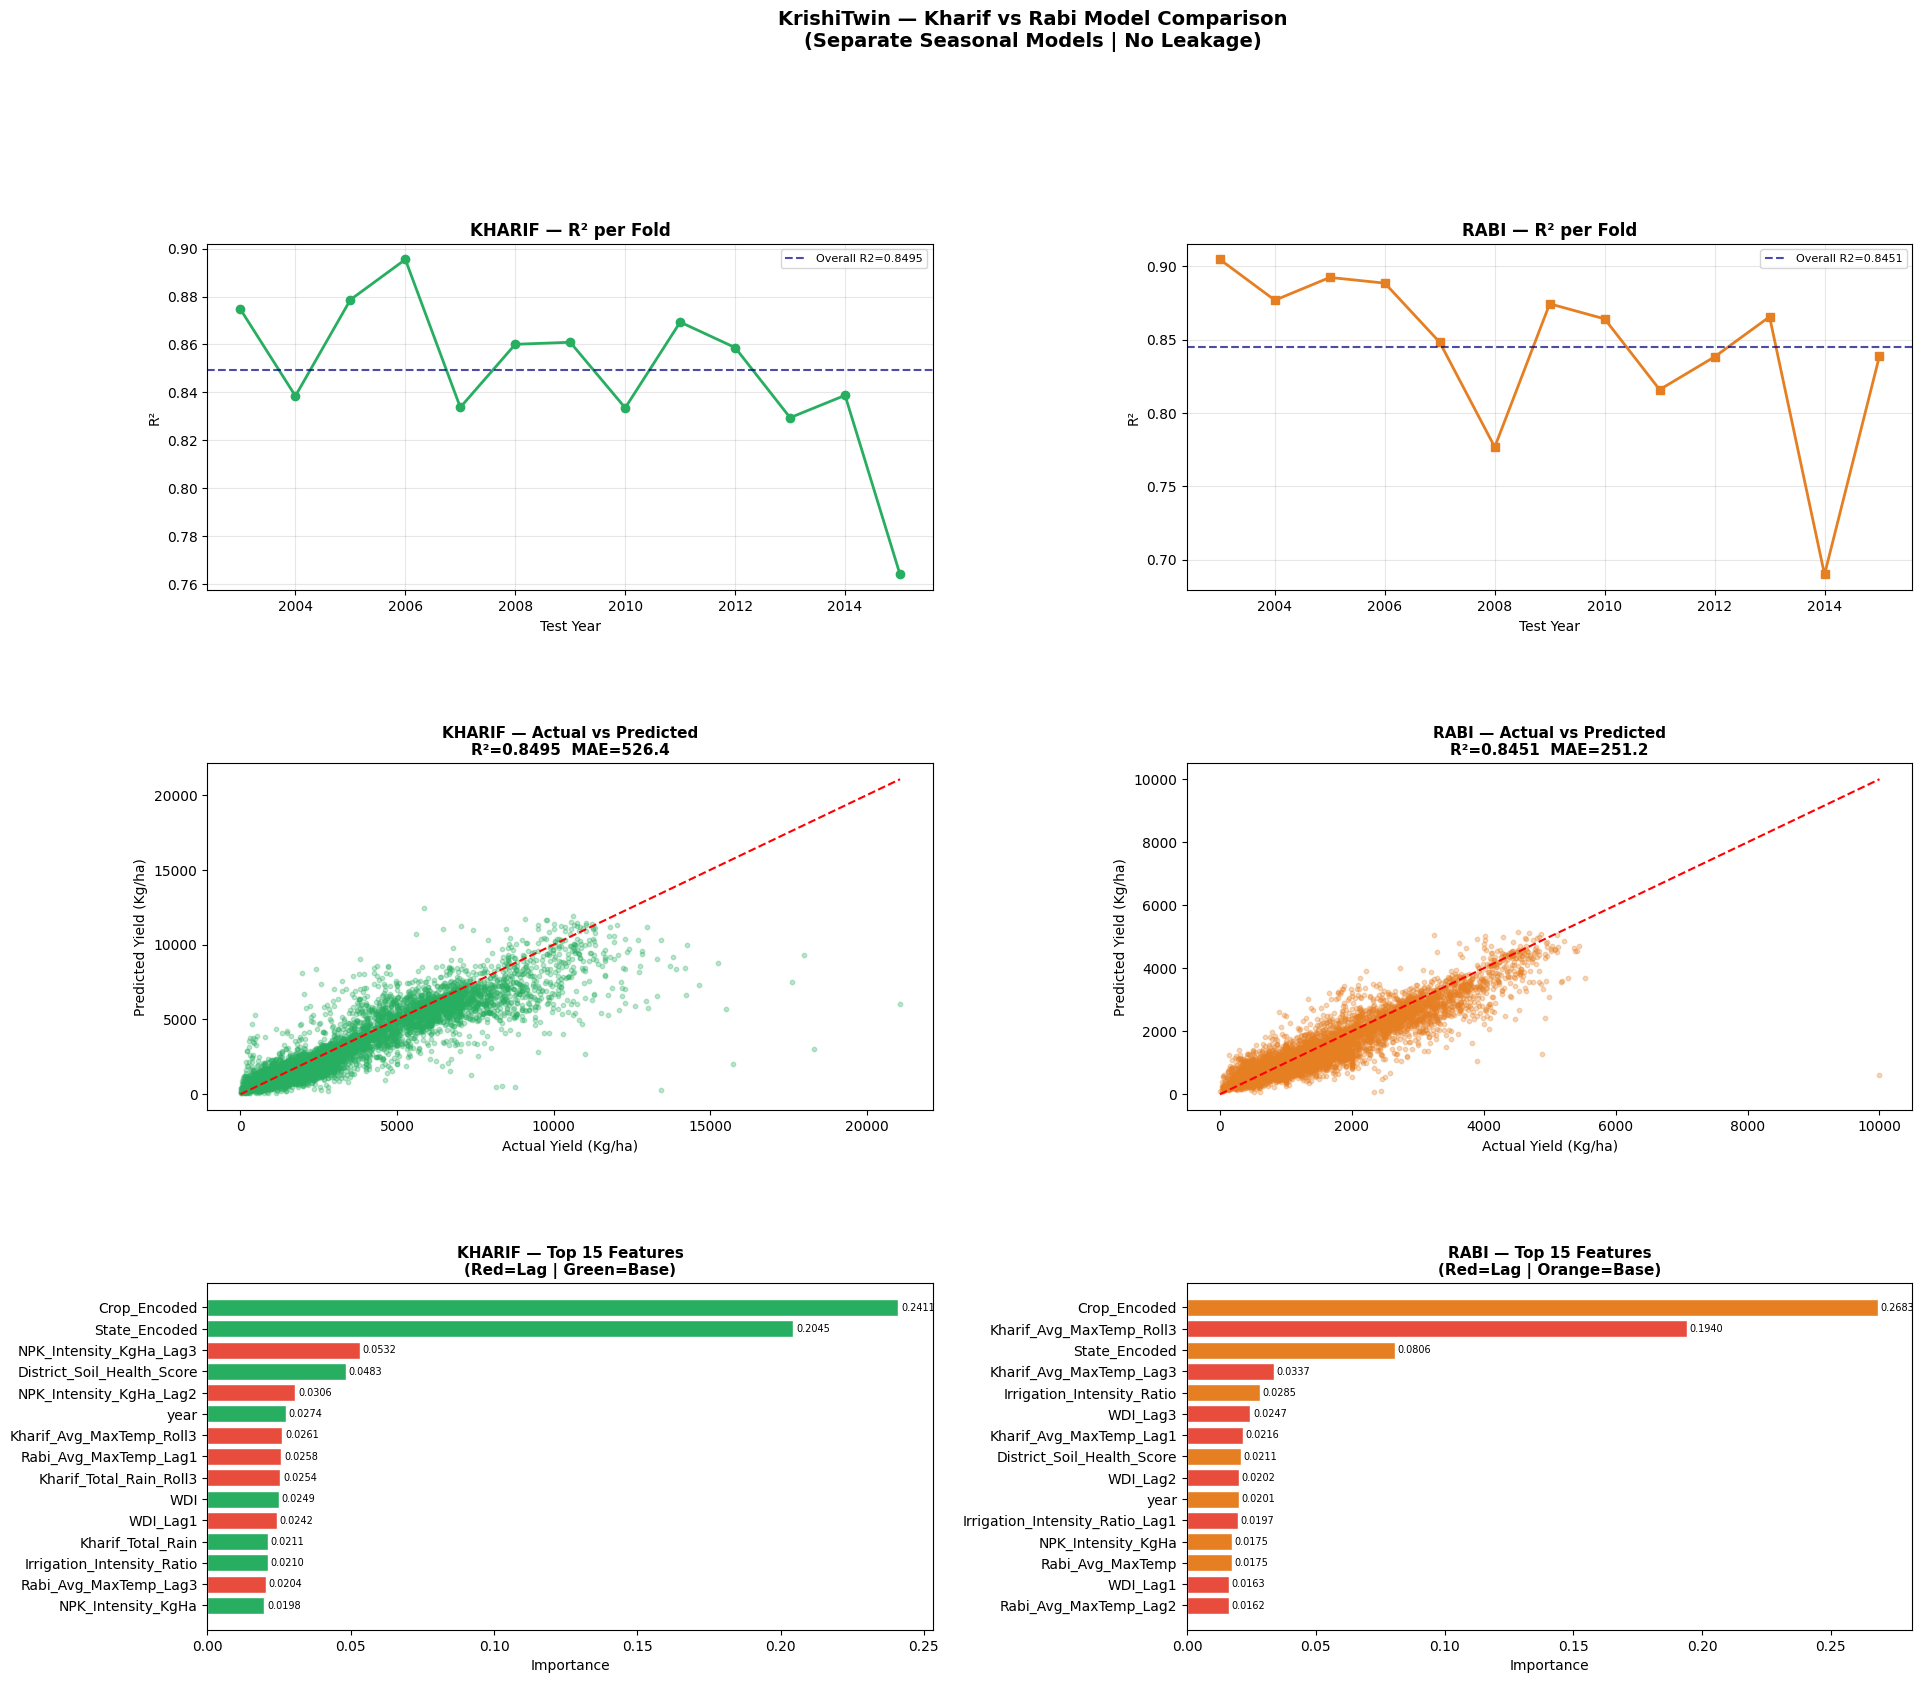

✅ Plot saved: KrishiTwin_Kharif_vs_Rabi_Results.png


In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — Comparison Plots: Kharif vs Rabi
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

# ── Row 1: R2 per fold ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(results_df_k['test_year'], results_df_k['r2'],
         marker='o', color='#27ae60', linewidth=2, markersize=6)
ax1.axhline(y=overall_r2_k, color='navy', linestyle='--', alpha=0.7,
            label=f'Overall R2={overall_r2_k:.4f}')
ax1.set_title('KHARIF — R² per Fold', fontsize=12, fontweight='bold')
ax1.set_xlabel('Test Year'); ax1.set_ylabel('R²')
ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(results_df_r['test_year'], results_df_r['r2'],
         marker='s', color='#e67e22', linewidth=2, markersize=6)
ax2.axhline(y=overall_r2_r, color='navy', linestyle='--', alpha=0.7,
            label=f'Overall R2={overall_r2_r:.4f}')
ax2.set_title('RABI — R² per Fold', fontsize=12, fontweight='bold')
ax2.set_xlabel('Test Year'); ax2.set_ylabel('R²')
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Row 2: Actual vs Predicted ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(all_actuals_k, all_preds_k, alpha=0.3, color='#27ae60', s=10)
lim_k = max(max(all_actuals_k), max(all_preds_k))
ax3.plot([0, lim_k], [0, lim_k], '--r', linewidth=1.5)
ax3.set_title(f'KHARIF — Actual vs Predicted\nR²={overall_r2_k:.4f}  MAE={overall_mae_k:.1f}',
              fontsize=11, fontweight='bold')
ax3.set_xlabel('Actual Yield (Kg/ha)'); ax3.set_ylabel('Predicted Yield (Kg/ha)')

ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(all_actuals_r, all_preds_r, alpha=0.3, color='#e67e22', s=10)
lim_r = max(max(all_actuals_r), max(all_preds_r))
ax4.plot([0, lim_r], [0, lim_r], '--r', linewidth=1.5)
ax4.set_title(f'RABI — Actual vs Predicted\nR²={overall_r2_r:.4f}  MAE={overall_mae_r:.1f}',
              fontsize=11, fontweight='bold')
ax4.set_xlabel('Actual Yield (Kg/ha)'); ax4.set_ylabel('Predicted Yield (Kg/ha)')

# ── Row 3: Feature Importance ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
top15_k = feat_imp_k.head(15)
colors_k = ['#e74c3c' if ('_Lag' in f or '_Delta' in f or '_Roll' in f)
            else '#27ae60' for f in top15_k['Feature']]
bars_k = ax5.barh(top15_k['Feature'][::-1], top15_k['Importance'][::-1],
                  color=colors_k[::-1], edgecolor='white')
ax5.set_title('KHARIF — Top 15 Features\n(Red=Lag | Green=Base)',
              fontsize=11, fontweight='bold')
ax5.set_xlabel('Importance')
for bar, val in zip(bars_k, top15_k['Importance'][::-1]):
    ax5.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7)

ax6 = fig.add_subplot(gs[2, 1])
top15_r = feat_imp_r.head(15)
colors_r = ['#e74c3c' if ('_Lag' in f or '_Delta' in f or '_Roll' in f)
            else '#e67e22' for f in top15_r['Feature']]
bars_r = ax6.barh(top15_r['Feature'][::-1], top15_r['Importance'][::-1],
                  color=colors_r[::-1], edgecolor='white')
ax6.set_title('RABI — Top 15 Features\n(Red=Lag | Orange=Base)',
              fontsize=11, fontweight='bold')
ax6.set_xlabel('Importance')
for bar, val in zip(bars_r, top15_r['Importance'][::-1]):
    ax6.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=7)

fig.suptitle('KrishiTwin — Kharif vs Rabi Model Comparison\n(Separate Seasonal Models | No Leakage)',
             fontsize=14, fontweight='bold', y=1.01)

plt.savefig('KrishiTwin_Kharif_vs_Rabi_Results.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print('✅ Plot saved: KrishiTwin_Kharif_vs_Rabi_Results.png')

In [ ]:
## 🔴 CELL 12 — Final Summary



🚀 Final Model Training on Full Data...
✅ Final model trained on full dataset


In [21]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Final Summary
# ═══════════════════════════════════════════════════════════════

print('=' * 68)
print('  KRISHITWIN — KHARIF vs RABI FINAL RESULTS')
print('=' * 68)
print(f'  {"Model":<35} {"R2":>8} {"MAE":>10} {"MAPE":>8}')
print('  ' + '-' * 65)
print(f'  {"Old (Single, Random Split, No Lag)":<35} {0.8052:>8.4f} {393.66:>10.2f} {"~30%":>8}')
print(f'  {"New Kharif (WalkFwd + Lag, No Leakage)":<35} {overall_r2_k:>8.4f} {overall_mae_k:>10.2f} {overall_mape_k:>7.1f}%')
print(f'  {"New Rabi   (WalkFwd + Lag, Rabi Temp)":<35} {overall_r2_r:>8.4f} {overall_mae_r:>10.2f} {overall_mape_r:>7.1f}%')
print('  ' + '=' * 65)
print()
print('  Saved Files:')
print('  📦 krishi_kharif_xgb_final.pkl   ← Kharif model')
print('  📦 krishi_rabi_xgb_final.pkl     ← Rabi model')
print('  📦 kharif_feature_list.pkl       ← Needed at inference')
print('  📦 rabi_feature_list.pkl         ← Needed at inference')
print('  📦 crop_encoder.pkl')
print('  📦 state_encoder.pkl')
print('  📊 KrishiTwin_Kharif_vs_Rabi_Results.png')
print('=' * 68)

  KRISHITWIN — KHARIF vs RABI FINAL RESULTS
  Model                                     R2        MAE     MAPE
  -----------------------------------------------------------------
  Old (Single, Random Split, No Lag)    0.8052     393.66     ~30%
  New Kharif (WalkFwd + Lag, No Leakage)   0.8495     526.42    29.2%
  New Rabi   (WalkFwd + Lag, Rabi Temp)   0.8451     251.16    24.5%

  Saved Files:
  📦 krishi_kharif_xgb_final.pkl   ← Kharif model
  📦 krishi_rabi_xgb_final.pkl     ← Rabi model
  📦 kharif_feature_list.pkl       ← Needed at inference
  📦 rabi_feature_list.pkl         ← Needed at inference
  📦 crop_encoder.pkl
  📦 state_encoder.pkl
  📊 KrishiTwin_Kharif_vs_Rabi_Results.png


NameError: name 'final_model' is not defined

✅ Walk-Forward Engineered data saved: KrishiTwin_WalkForward_Engineered.csv


✅ Total features for model: 33

⏳ Grid Search chal raha hai (with Walk-Forward Validation)...
Fitting 13 folds for each of 162 candidates, totalling 2106 fits


KeyboardInterrupt: 

### GPU;-

### Randomized CV with GPUs:-

✅ Total features for model: 33

⏳ Randomized Search chal raha hai (GPU + Walk-Forward Validation)...
Fitting 13 folds for each of 25 candidates, totalling 325 fits

✅ RandomizedSearch Complete! Best Params Found:
   subsample: 0.9
   reg_lambda: 2.0
   n_estimators: 700
   min_child_weight: 7
   max_depth: 10
   learning_rate: 0.05
   colsample_bytree: 0.7

🚀 Walk-Forward Training Shuru (With Tuned Model on GPU)...
   Fold   Test Year    Train Rows   Test Rows          R2        MAE     MAPE
   ------------------------------------------------------------------------
   1      2003         45002        4530           0.8601      293.1    40.6%
   2      2004         49532        4552           0.8558      287.0    30.0%
   3      2005         54084        4611           0.8532      281.9    27.9%
   4      2006         58695        4578           0.8804      276.8    30.0%
   5      2007         63273        4483           0.8253      331.2    29.1%
   6      2008         67756        4

## CELL 9 — Final Model (Poore Data par Train)

🔨 Final Production Model Training on Full Data...
✅ Final model saved: krishi_twin_xgb_model.pkl
   Train R2 (sanity): 0.8624  (should be high — this is train data)
   Walk-Fwd R2      : 0.8369  ← Yeh actual generalization metric hai


## CELL 10 — Feature Importance

📊 Top 20 Feature Importances:
                        Feature  Importance
                   Crop_Encoded    0.196744
                  State_Encoded    0.070706
             NPK_Intensity_KgHa    0.060548
       Kharif_Avg_MaxTemp_Roll3    0.060056
     Irrigation_Intensity_Ratio    0.052225
        NPK_Intensity_KgHa_Lag3    0.035319
     District_Soil_Health_Score    0.029548
              Kharif_Total_Rain    0.027337
                           year    0.027291
Irrigation_Intensity_Ratio_Lag3    0.027077
          Rabi_Avg_MaxTemp_Lag1    0.025830
               Rabi_Avg_MaxTemp    0.023795
        NPK_Intensity_KgHa_Lag2    0.023548
Irrigation_Intensity_Ratio_Lag1    0.023245
                       WDI_Lag1    0.022511
                       WDI_Lag2    0.022432
Irrigation_Intensity_Ratio_Lag2    0.022409
        Kharif_Total_Rain_Roll3    0.022187
                            WDI    0.021934
             Kharif_Avg_MaxTemp    0.021346

🔍 Lag/Delta/Roll features total importance : 

## CELL 11 — Plots

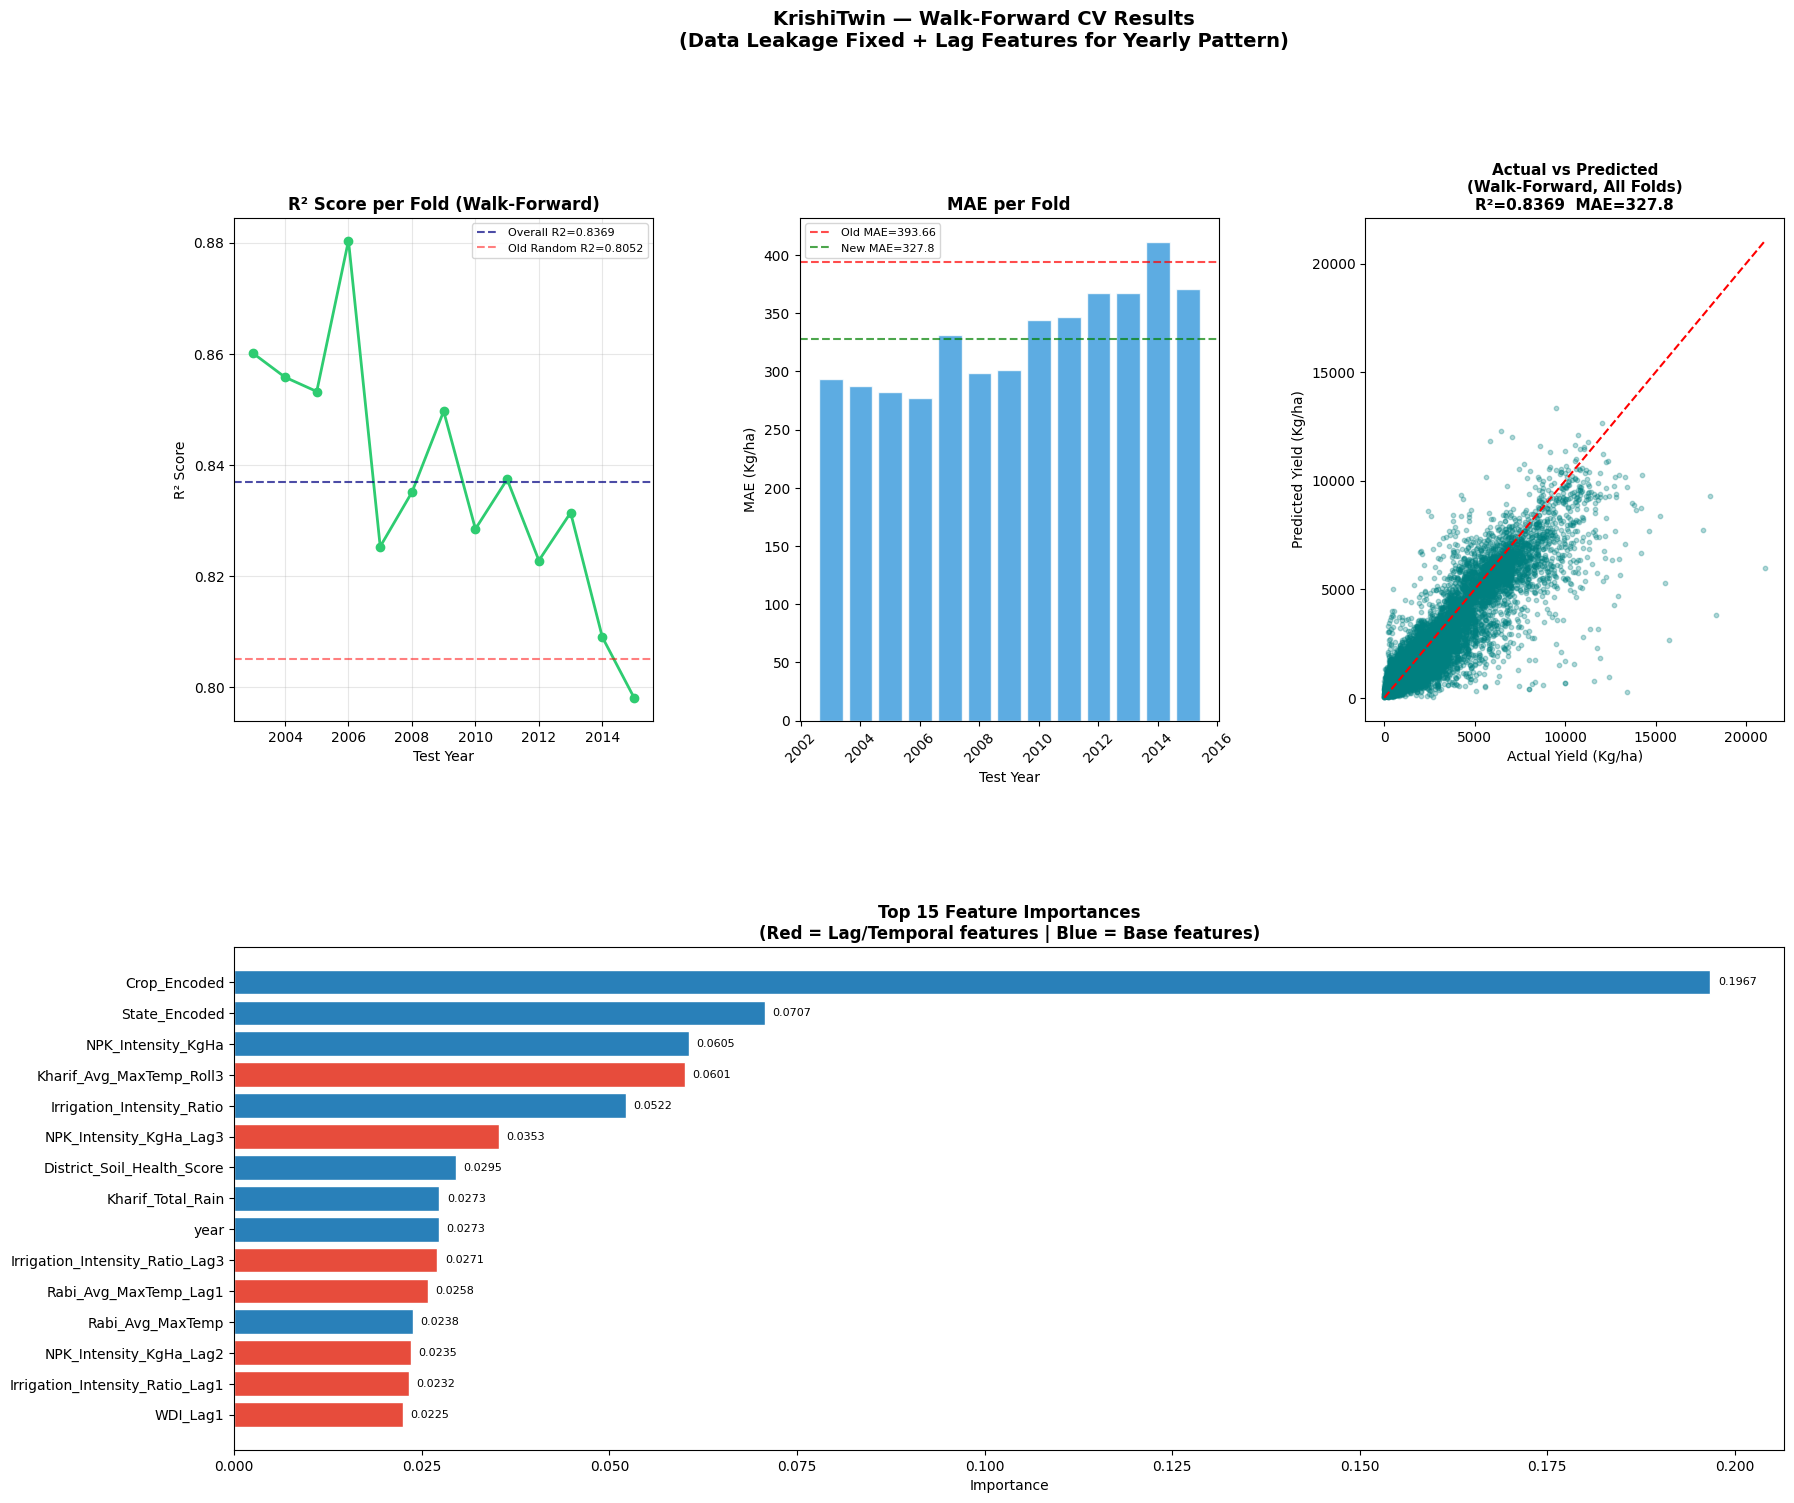

✅ Plot saved: KrishiTwin_WalkForward_Results.png


## CELL 12 — Summary

  KRISHITWIN — FINAL RESULTS SUMMARY
                                            R2        MAE     MAPE
  ---------------------------------------------------------------
  Old Model (Random Split, No Lag)      0.8052     393.66     ~30%
  New Model (Walk-Forward + Lag)        0.8369     327.80    33.6%

  Problems Fixed:
  ✅ Data Leakage      — Walk-Forward split, koi shuffle nahi
  ✅ Yearly Pattern     — Lag1/Lag2/Lag3 + Delta + Rolling features
  ✅ Skewed Yields      — Log Transform
  ✅ Overfitting        — min_child_weight + L1/L2 regularization

  Saved Files:
  📦 krishi_twin_xgb_model.pkl
  📦 crop_encoder.pkl
  📦 state_encoder.pkl
  📊 KrishiTwin_WalkForward_Results.png
